# **Importing Necessary Libraries and Dependencies**

In [16]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import skew, kurtosis, entropy
from numpy.fft import fft
from tqdm import tqdm
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# **Importing the Dataset Folder**

In [3]:
# Path to my EARBUDS folder
data_folder = "/kaggle/input/earbudss/EARBUDS"

# Listing all CSV files
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# Extracting relevant info from filenames
data = []
for filename in csv_files:
    parts = filename.split('-')
    person_id = int(parts[0])
    action = parts[1]
    side = parts[-1].replace('.csv', '')
    label = f"{action}-{side}"
    
    data.append({
        'filename': filename,
        'person_id': person_id,
        'action': label,
        'filepath': os.path.join(data_folder, filename)
    })

# Creating DataFrame
df_index = pd.DataFrame(data)
df_index.head()

,filename,person_id,action,filepath
0,10-running-imu-left.csv,10,running-left,/kaggle/input/earbudss/EARBUDS/10-running-imu-...
1,8-shake-imu-left.csv,8,shake-left,/kaggle/input/earbudss/EARBUDS/8-shake-imu-lef...
2,17-swallowing-imu-right.csv,17,swallowing-right,/kaggle/input/earbudss/EARBUDS/17-swallowing-i...
3,15-chewing-imu-left.csv,15,chewing-left,/kaggle/input/earbudss/EARBUDS/15-chewing-imu-...
4,13-still-imu-left.csv,13,still-left,/kaggle/input/earbudss/EARBUDS/13-still-imu-le...


In [4]:
# Counting the number of files per action
action_counts = df_index['action'].value_counts()

# Keep only actions with more than 5 files
valid_actions = action_counts[action_counts >= 5].index

# Filtering the DataFrame
df_index_filtered = df_index[df_index['action'].isin(valid_actions)].reset_index(drop=True)

print(f"Remaining Actions: {df_index_filtered['action'].nunique()}")
print("Actions kept:\n", df_index_filtered['action'].value_counts())

Remaining Actions: 30
Actions kept:
 action
wink-right          59
wink-left           59
eyes-right          58
brow-right          58
eyes-left           58
brow-left           58
running-left        31
running-right       31
lip-right           29
swallowing-left     29
nod-left            29
chin-right          29
tilt-right          29
speaking-right      29
tilt-left           29
chewing-right       29
walking-left        29
lip-left            29
nod-right           29
shake-left          29
chin-left           29
shake-right         29
still-right         29
speaking-left       29
still-left          29
chewing-left        29
swallowing-right    29
walking-right       29
mouth-left          28
mouth-right         28
Name: count, dtype: int64


# **Feature Engineering**

In [5]:
# Butterworth filter
def butterworth_filter(data, cutoff=3, fs=50, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# FFT
def compute_fft(signal):
    fft_vals = np.abs(fft(signal))
    return fft_vals[:len(fft_vals)//2]

# Derivative (jerk)
def compute_jerk(signal):
    return np.diff(signal)

# Vector magnitude
def vector_magnitude(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

# Cross-correlation between two signals
def cross_corr(a, b):
    return np.correlate(a - np.mean(a), b - np.mean(b), mode='valid')[0]

# Extracting features from one signal
def extract_signal_features(signal, signal_name):
    features = {}
    fft_vals = compute_fft(signal)
    jerk = compute_jerk(signal)
    
    # Time domain
    features[f'{signal_name}_mean'] = np.mean(signal)
    features[f'{signal_name}_std'] = np.std(signal)
    features[f'{signal_name}_max'] = np.max(signal)
    features[f'{signal_name}_min'] = np.min(signal)
    features[f'{signal_name}_range'] = np.ptp(signal)
    features[f'{signal_name}_median'] = np.median(signal)
    features[f'{signal_name}_skew'] = skew(signal)
    features[f'{signal_name}_kurtosis'] = kurtosis(signal)
    features[f'{signal_name}_iqr'] = np.percentile(signal, 75) - np.percentile(signal, 25)
    features[f'{signal_name}_energy'] = np.sum(signal**2)
    
    # Frequency domain
    features[f'{signal_name}_fft_energy'] = np.sum(fft_vals**2)
    features[f'{signal_name}_fft_peak'] = np.argmax(fft_vals)
    features[f'{signal_name}_fft_entropy'] = entropy(fft_vals + 1e-8)  # avoid log(0)
    
    # Jerk
    features[f'{signal_name}_jerk_mean'] = np.mean(jerk)
    features[f'{signal_name}_jerk_max'] = np.max(jerk)
    features[f'{signal_name}_jerk_std'] = np.std(jerk)
    
    # Peaks and troughs
    peaks, _ = find_peaks(signal)
    troughs, _ = find_peaks(-signal)
    features[f'{signal_name}_num_peaks'] = len(peaks)
    features[f'{signal_name}_num_troughs'] = len(troughs)
    features[f'{signal_name}_peak_trough_diff'] = len(peaks) - len(troughs)
    
    # Zero-crossing
    zero_crossings = np.where(np.diff(np.sign(signal)))[0]
    features[f'{signal_name}_zero_crossings'] = len(zero_crossings)
    
    return features

# Main feature extraction
def extract_all_features(df):
    feats = {}

    # Applying Butterworth and extracting features per column
    signals = {}
    for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
        filtered = butterworth_filter(df[col].values)
        signals[col] = filtered
        feats.update(extract_signal_features(filtered, col))

    # Magnitude features
    acc_mag = vector_magnitude(signals['ax'], signals['ay'], signals['az'])
    gyro_mag = vector_magnitude(signals['gx'], signals['gy'], signals['gz'])
    feats.update(extract_signal_features(acc_mag, 'acc_mag'))
    feats.update(extract_signal_features(gyro_mag, 'gyro_mag'))

    # Cross-correlations
    feats['corr_ax_ay'] = cross_corr(signals['ax'], signals['ay'])
    feats['corr_gy_gz'] = cross_corr(signals['gy'], signals['gz'])

    return feats

# Splitting the CSV time series into overlapping windows and extracting features per window
def process_file_windowed(filepath, label, person_id, filename, fs=50, window_sec=2, step_sec=1):
    df = pd.read_csv(filepath)
    window_size = fs * window_sec
    step_size = fs * step_sec
    total_samples = len(df)

    features_list = []

    for start in range(0, total_samples - window_size + 1, step_size):
        end = start + window_size
        window_df = df.iloc[start:end]

        # Skipping windows with NaNs or weird data
        if window_df.isnull().values.any():
            continue

        try:
            features = extract_all_features(window_df)
            features['label'] = label
            features['filename'] = filename
            features['person_id'] = person_id
            features_list.append(features)
        except Exception as e:
            print(f"Skipping window due to error: {e}")
            continue

    return features_list

all_windowed_features = []

for _, row in tqdm(df_index_filtered.iterrows(), total=len(df_index_filtered)):
    feats = process_file_windowed(row['filepath'], row['action'], row['person_id'], row['filename'])
    all_windowed_features.extend(feats)

# Converting to DataFrame
df_features_windowed = pd.DataFrame(all_windowed_features)

100%|██████████| 1048/1048 [1:38:45<00:00,  5.65s/it]


In [6]:
df_features_windowed.head()

,ax_mean,ax_std,ax_max,ax_min,ax_range,ax_median,ax_skew,ax_kurtosis,ax_iqr,ax_energy,...,gyro_mag_jerk_std,gyro_mag_num_peaks,gyro_mag_num_troughs,gyro_mag_peak_trough_diff,gyro_mag_zero_crossings,corr_ax_ay,corr_gy_gz,label,filename,person_id
0,-2797.875505,2746.170005,2445.825753,-7289.181611,9735.007364,-3186.659725,0.237489,-0.956932,3948.039016,1.536956e+09,...,374.569454,5,4,1,0,1.855791e+09,1.483520e+08,running-left,10-running-imu-left.csv,10
1,-1350.003542,2739.899361,2700.780301,-8344.164728,11044.945028,-1268.310863,-0.221321,-0.818472,4720.705823,9.329558e+08,...,405.490052,5,6,-1,0,1.954116e+09,2.354508e+08,running-left,10-running-imu-left.csv,10
2,-1323.408930,2159.620342,2619.954983,-5010.674637,7630.629620,-1319.130899,0.223372,-1.002838,3332.560942,6.415371e+08,...,430.294172,6,6,0,0,1.244240e+09,1.395265e+08,running-left,10-running-imu-left.csv,10
3,-1848.026063,2119.321062,2029.424716,-5175.006494,7204.431210,-1969.185460,0.189679,-1.100807,3433.002518,7.906722e+08,...,429.084400,5,6,-1,0,1.311047e+09,1.182992e+08,running-left,10-running-imu-left.csv,10
4,-1825.413698,2483.784058,2029.884636,-6313.865802,8343.750438,-1819.106208,-0.062985,-1.238616,4178.269748,9.501318e+08,...,373.512670,5,6,-1,0,1.669900e+09,6.177366e+07,running-left,10-running-imu-left.csv,10


# **LightGBM**

In [11]:
# Label encoding
le = LabelEncoder()
df_features_windowed['encoded_label'] = le.fit_transform(df_features_windowed['label'])

# Save person_id before splitting
person_ids = df_features_windowed['person_id'].values

# Selecting features
feature_cols = [col for col in df_features_windowed.columns if col not in ['label', 'encoded_label', 'filename', 'person_id']]
X = df_features_windowed[feature_cols]
y = df_features_windowed['encoded_label']

# Splitting
X_train, X_test, y_train, y_test, person_id_train, person_id_test = train_test_split(
    X, y, person_ids, stratify=y, test_size=0.2, random_state=42
)

# Model
lgb_clf = LGBMClassifier(
    objective='multiclass',
    num_class=len(le.classes_),
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    random_state=42,
    n_estimators=1000
)

# Training with callbacks
lgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100)
    ]
)

# Predicting and evaluating
y_pred = lgb_clf.predict(X_test)
df_test = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'person_id': person_id_test
})
# Collecting scores per person
person_scores = []
for person_id in sorted(df_test['person_id'].unique()):
    df_p = df_test[df_test['person_id'] == person_id]
    y_true_p = df_p['y_true']
    y_pred_p = df_p['y_pred']
    
    person_scores.append({
        'person_id': person_id,
        'Accuracy': accuracy_score(y_true_p, y_pred_p),
        'Precision': precision_score(y_true_p, y_pred_p, average='weighted', zero_division=0),
        'Recall': recall_score(y_true_p, y_pred_p, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true_p, y_pred_p, average='weighted', zero_division=0)
    })

df_person_scores = pd.DataFrame(person_scores)
acc = accuracy_score(y_test, y_pred)
print()
print(f"LightGBM Accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.277570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31381
[LightGBM] [Info] Number of data points in the train set: 209076, number of used features: 158
[LightGBM] [Info] Start training from score -2.894109
[LightGBM] [Info] Start training from score -2.890831
[LightGBM] [Info] Start training from score -3.619039
[LightGBM] [Info] Start training from score -3.615299
[LightGBM] [Info] Start training from score -3.587429
[LightGBM] [Info] Start training from score -3.583978
[LightGBM] [Info] Start training from score -2.894023
[LightGBM] [Info] Start training from score -2.890831
[LightGBM] [Info] Start training from score -3.587602
[LightGBM] [Info] Start training from score -3.583978
[LightGBM] [Info] Start training from score -3.622434
[LightGBM] [Info] Start training from score -3.618860
[LightGBM] [Info] Start training from score -3.587084
[Light

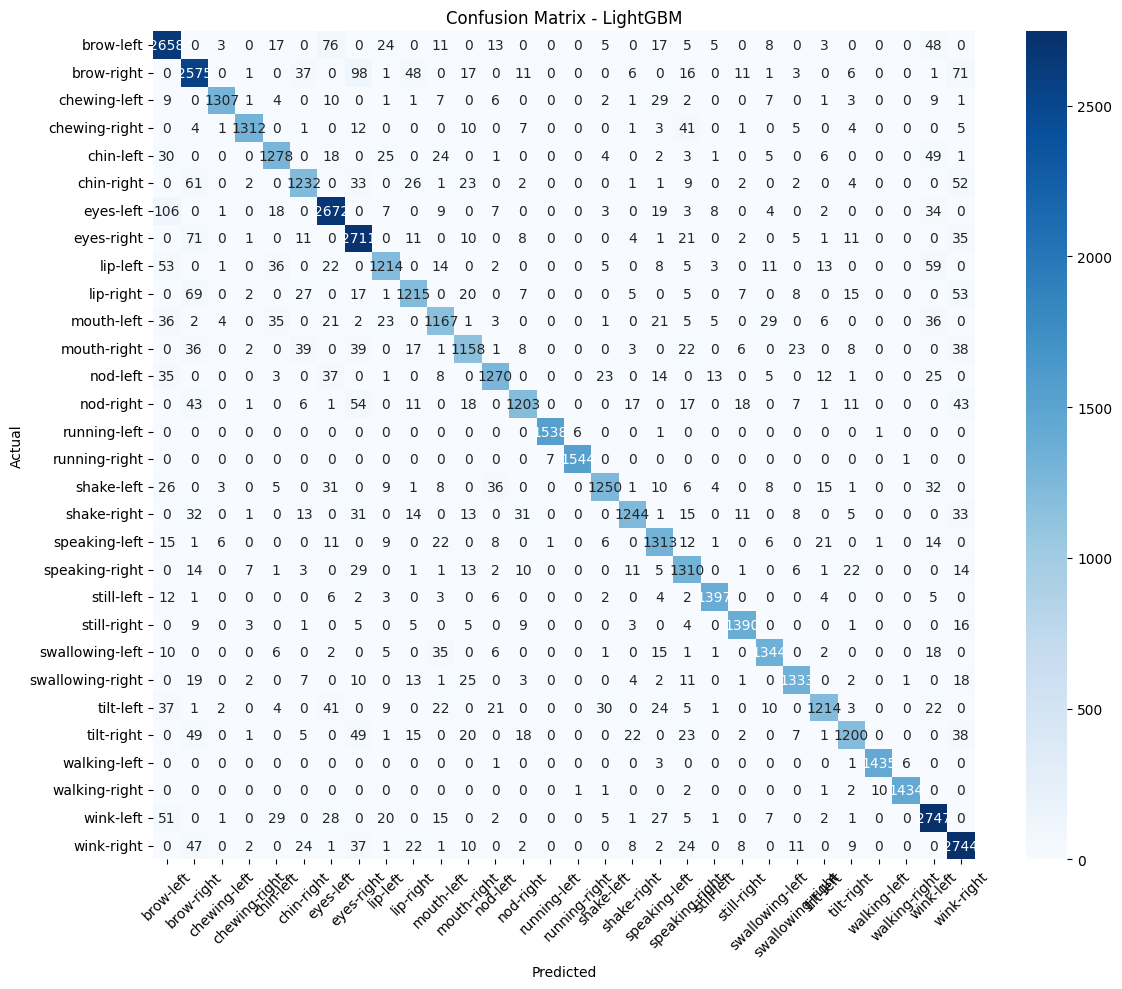

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

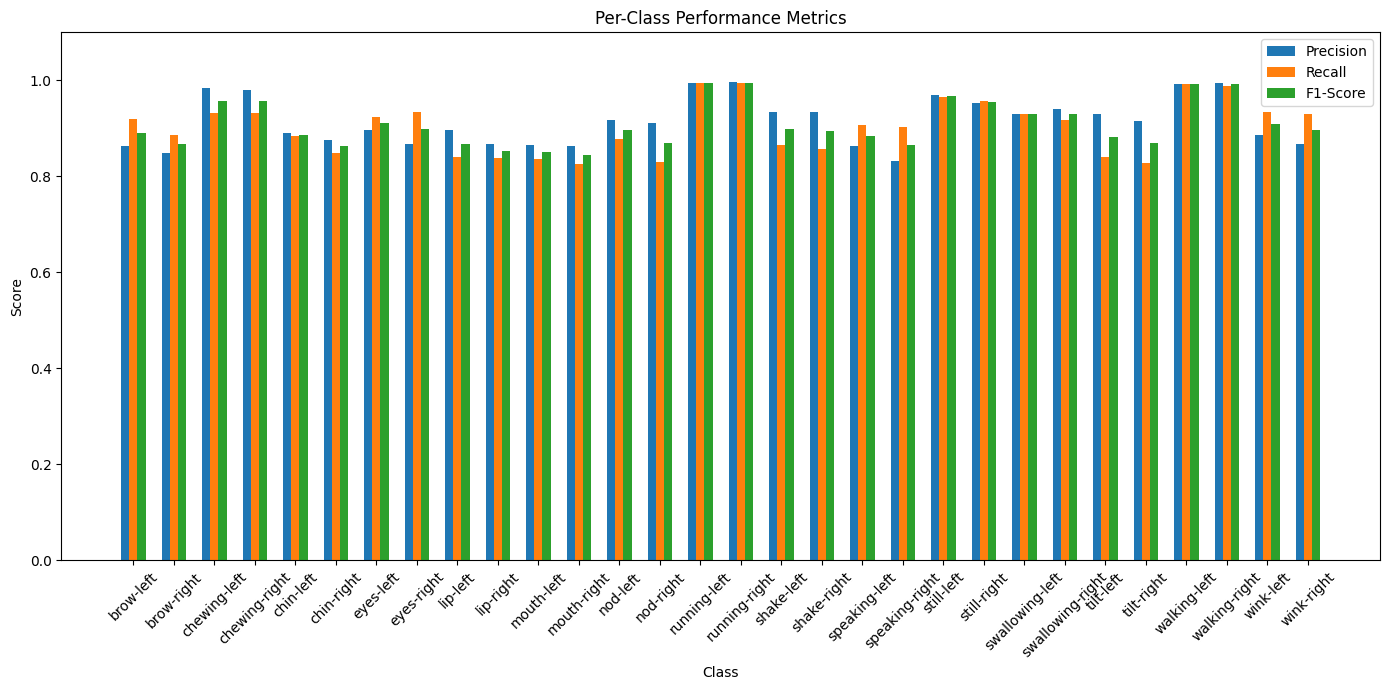

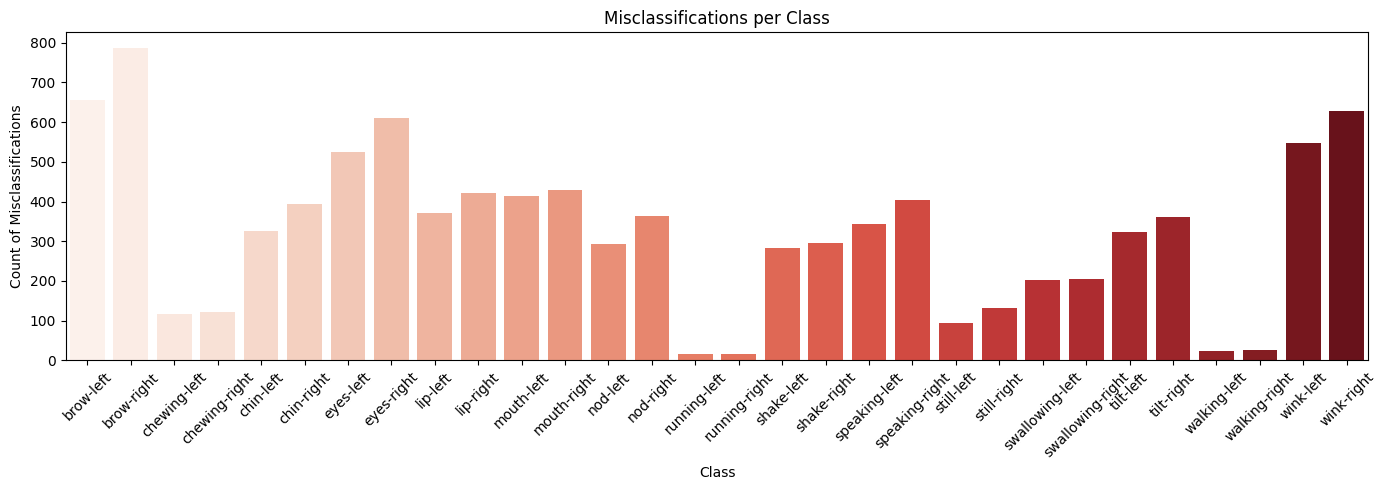

In [13]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
best_person = df_person_scores.loc[df_person_scores['Accuracy'].idxmax()]
print(f"Highest Accuracy for LightGBM: {best_person['Accuracy']:.2%} by Person {int(best_person['person_id'])}")

Highest Accuracy for LightGBM: 98.92% by Person 27


In [15]:
best_person = df_person_scores.loc[df_person_scores['F1-Score'].idxmax()]
print(f"Highest F1-score for LightGBM: {best_person['F1-Score']:.2%} by Person {int(best_person['person_id'])}")

Highest F1-score for LightGBM: 98.92% by Person 27


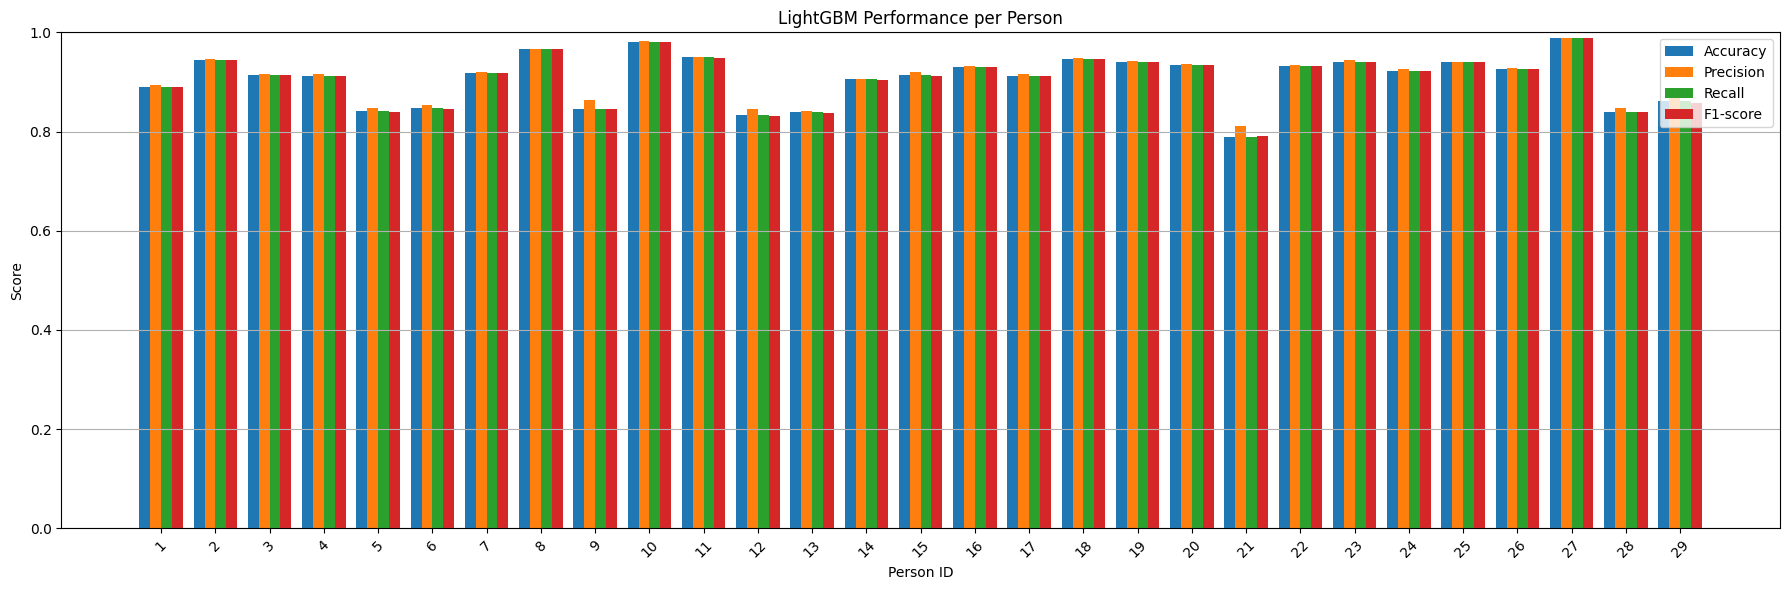

In [16]:
# Metrics and colour map
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

x = np.arange(len(df_person_scores))  # person indices
width = 0.2

fig, ax = plt.subplots(figsize=(18, 6))

for i, metric in enumerate(metrics):
    ax.bar(
        x + i * width,
        df_person_scores[metric],
        width,
        label=metric.capitalize(),
        color=colors[i]
    )

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(df_person_scores['person_id'].astype(str), rotation=45)
ax.set_xlabel('Person ID')
ax.set_ylabel('Score')
ax.set_title('LightGBM Performance per Person')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# **XGBoost**

In [17]:
# XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    max_depth=10,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Per-person evaluation
person_scores = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred = xgb_model.predict(X_person)

    acc = accuracy_score(y_person, y_pred)
    prec = precision_score(y_person, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred, average='macro', zero_division=0)

    person_scores.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores = pd.DataFrame(person_scores)

# Evaluation
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

XGBoost Accuracy: 89.75%

                  precision    recall  f1-score   support

       brow-left       0.86      0.91      0.89      2893
      brow-right       0.85      0.87      0.86      2903
    chewing-left       0.96      0.93      0.95      1401
   chewing-right       0.96      0.93      0.95      1407
       chin-left       0.87      0.89      0.88      1447
      chin-right       0.87      0.83      0.85      1451
       eyes-left       0.88      0.91      0.90      2893
      eyes-right       0.86      0.93      0.89      2903
        lip-left       0.90      0.81      0.85      1446
       lip-right       0.86      0.83      0.85      1451
      mouth-left       0.87      0.82      0.84      1397
     mouth-right       0.85      0.81      0.83      1401
        nod-left       0.91      0.87      0.89      1447
       nod-right       0.90      0.81      0.85      1451
    running-left       0.99      0.99      0.99      1546
   running-right       0.99      0.99      0.

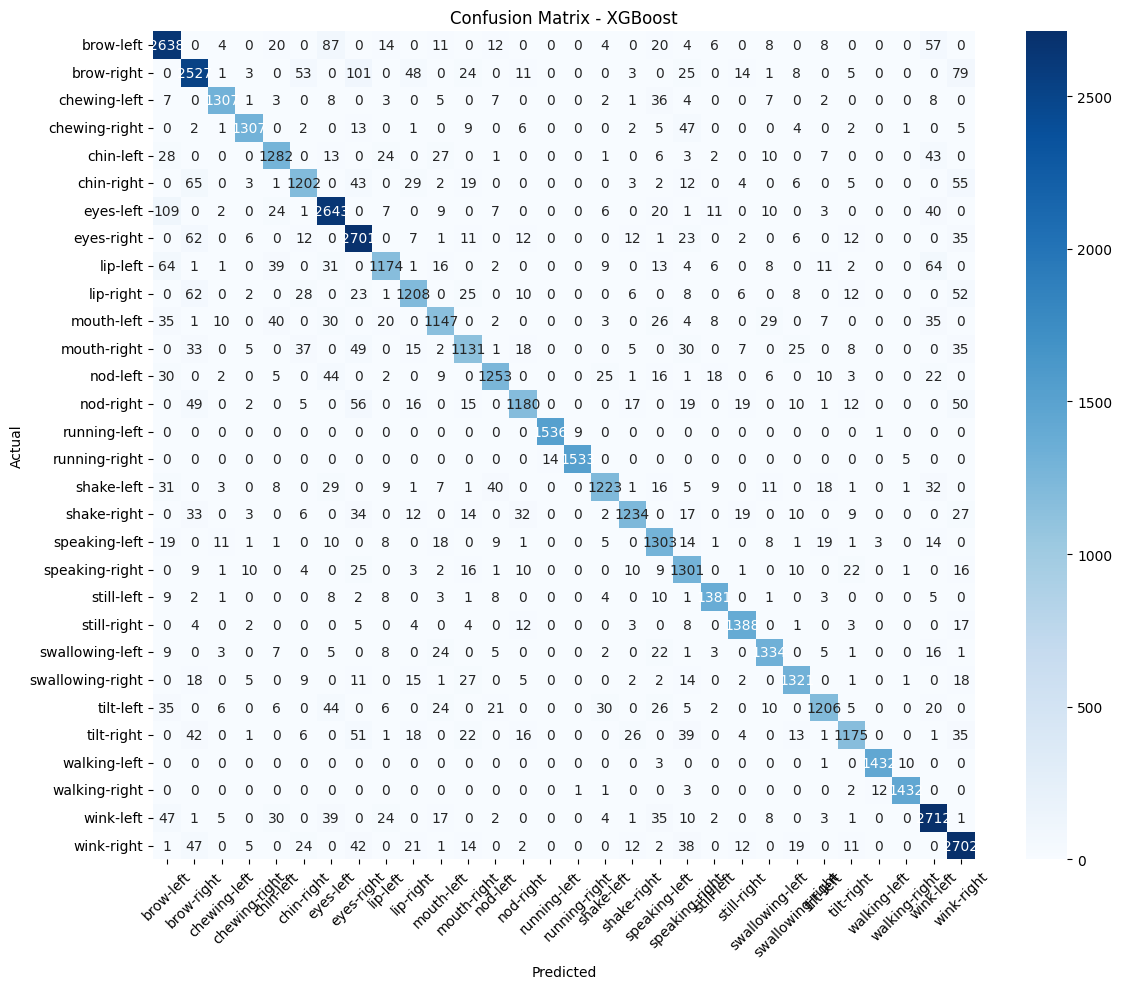

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

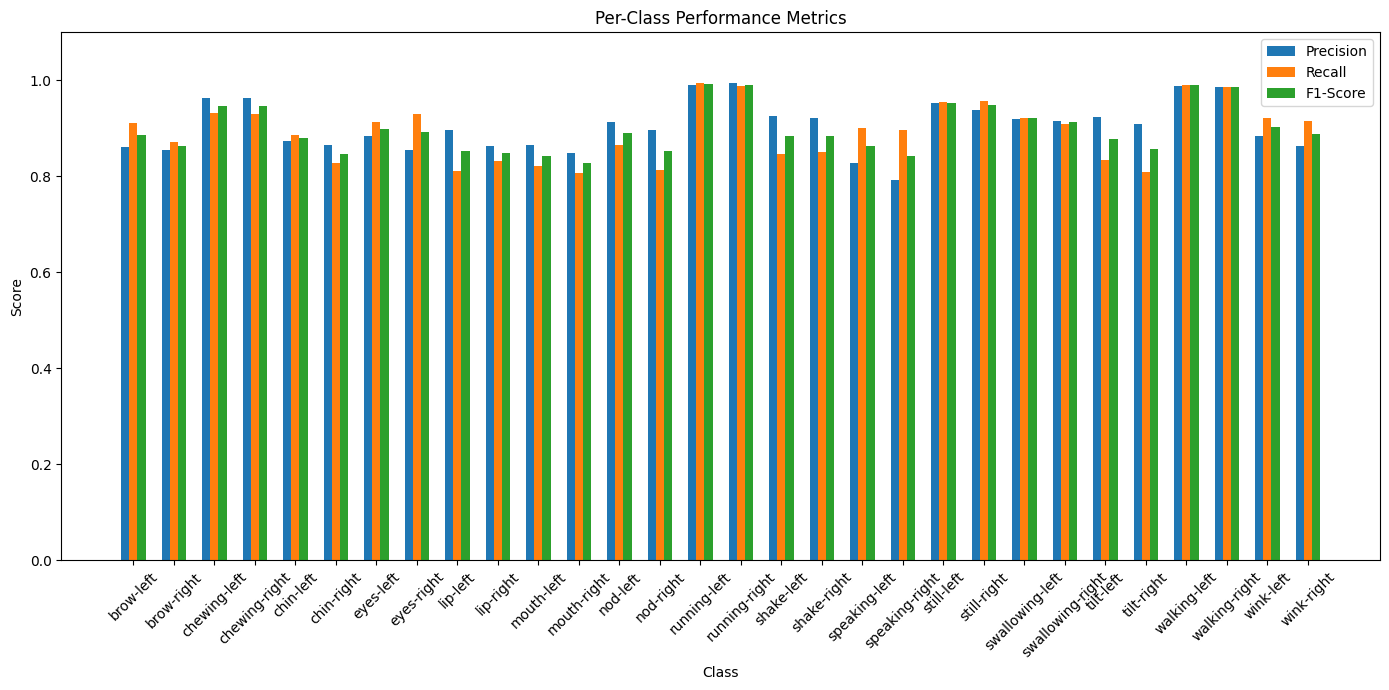

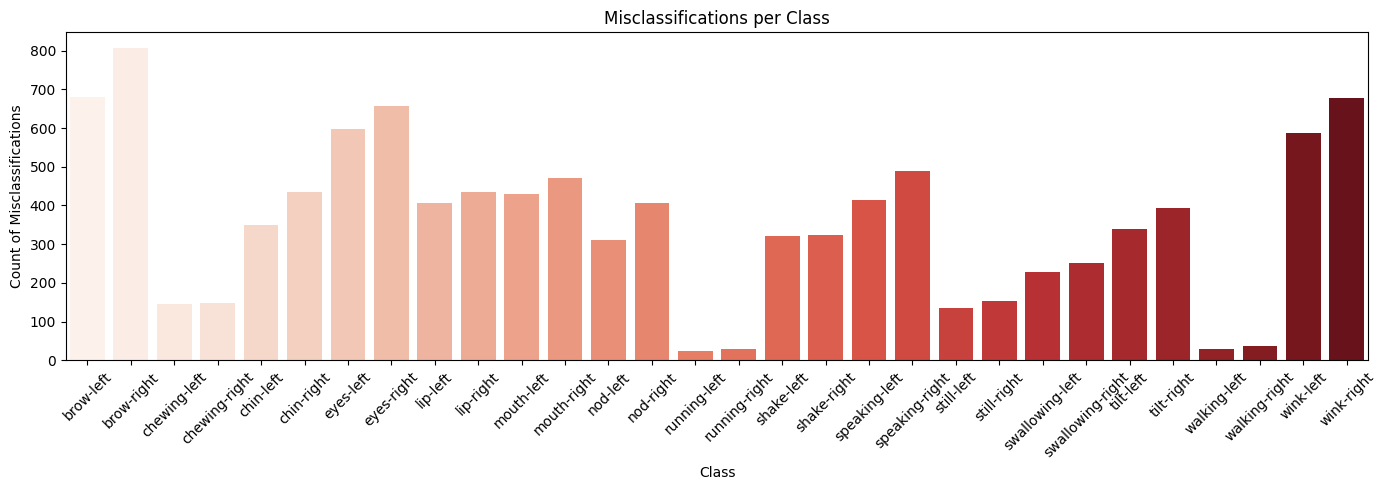

In [19]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Printing best performer
best_person = df_person_scores.loc[df_person_scores['Accuracy'].idxmax()]
print(f"Highest Accuracy for XGBoost: {best_person['Accuracy']:.2%} by Person {int(best_person['person_id'])}")

Highest Accuracy for XGBoost: 98.74% by Person 27


In [21]:
# Person with highest F1 score
best_person = df_person_scores.loc[df_person_scores['F1-Score'].idxmax()]
print(f"Highest F1-score for XGBoost: {best_person['F1-Score']:.2%} by Person {int(best_person['person_id'])}")

Highest F1-score for XGBoost: 98.84% by Person 27


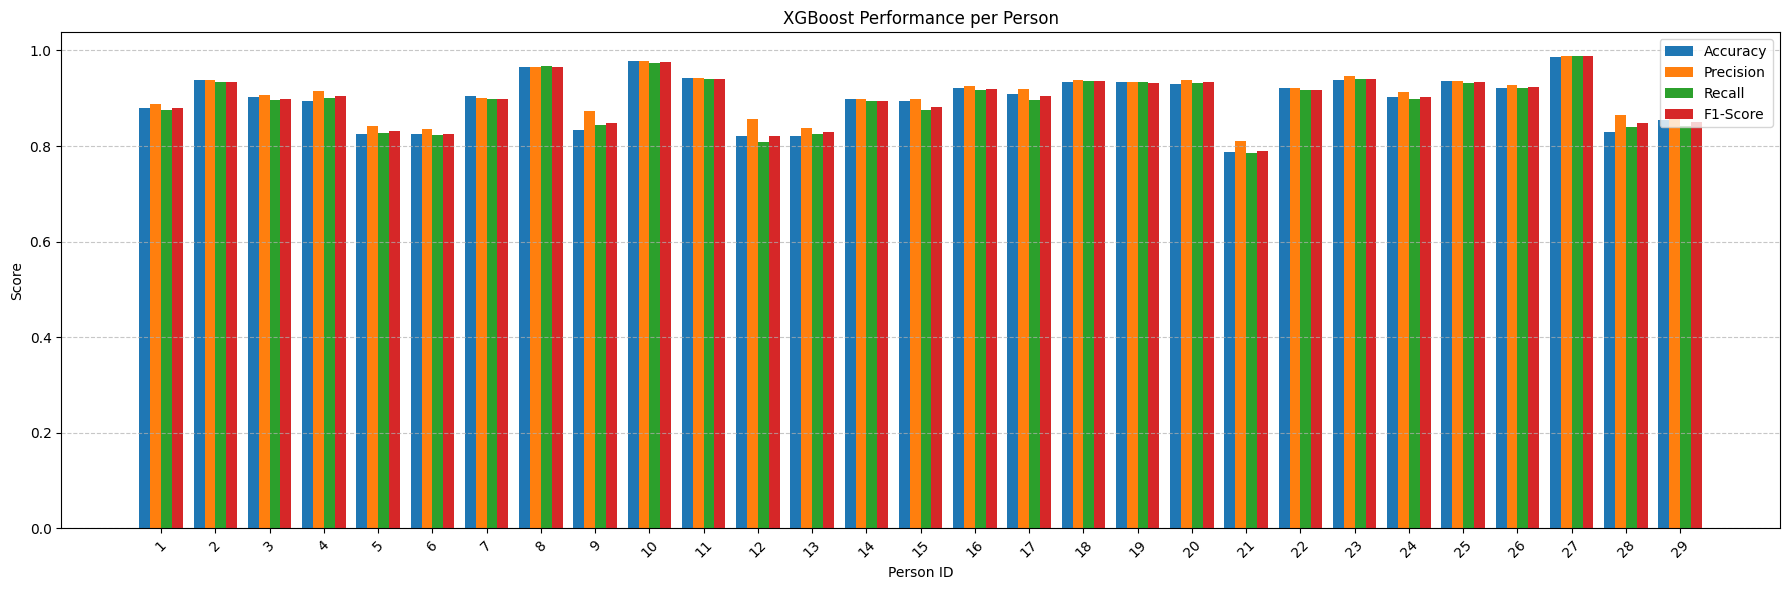

In [22]:
plt.figure(figsize=(18, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores))
width = 0.2

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("XGBoost Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **ExtraTrees Classifier**

In [23]:
# Training ExtraTrees
et_model = ExtraTreesClassifier(n_estimators=400, random_state=42)
et_model.fit(X_train, y_train)

# Per-person evaluation
person_scores_et = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred_person = et_model.predict(X_person)

    acc = accuracy_score(y_person, y_pred_person)
    prec = precision_score(y_person, y_pred_person, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred_person, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred_person, average='macro', zero_division=0)

    person_scores_et.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores_et = pd.DataFrame(person_scores_et)
y_pred_et = et_model.predict(X_test)
acc = accuracy_score(y_test, y_pred_et)
print(f"ExtraTrees Accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred_et, target_names=le.classes_))

ExtraTrees Accuracy: 90.18%

                  precision    recall  f1-score   support

       brow-left       0.86      0.92      0.89      2893
      brow-right       0.88      0.89      0.88      2903
    chewing-left       0.91      0.94      0.93      1401
   chewing-right       0.91      0.95      0.93      1407
       chin-left       0.90      0.90      0.90      1447
      chin-right       0.89      0.87      0.88      1451
       eyes-left       0.90      0.92      0.91      2893
      eyes-right       0.87      0.93      0.90      2903
        lip-left       0.93      0.83      0.87      1446
       lip-right       0.89      0.84      0.87      1451
      mouth-left       0.88      0.81      0.84      1397
     mouth-right       0.87      0.82      0.84      1401
        nod-left       0.93      0.86      0.89      1447
       nod-right       0.94      0.81      0.87      1451
    running-left       0.98      0.99      0.99      1546
   running-right       1.00      0.98     

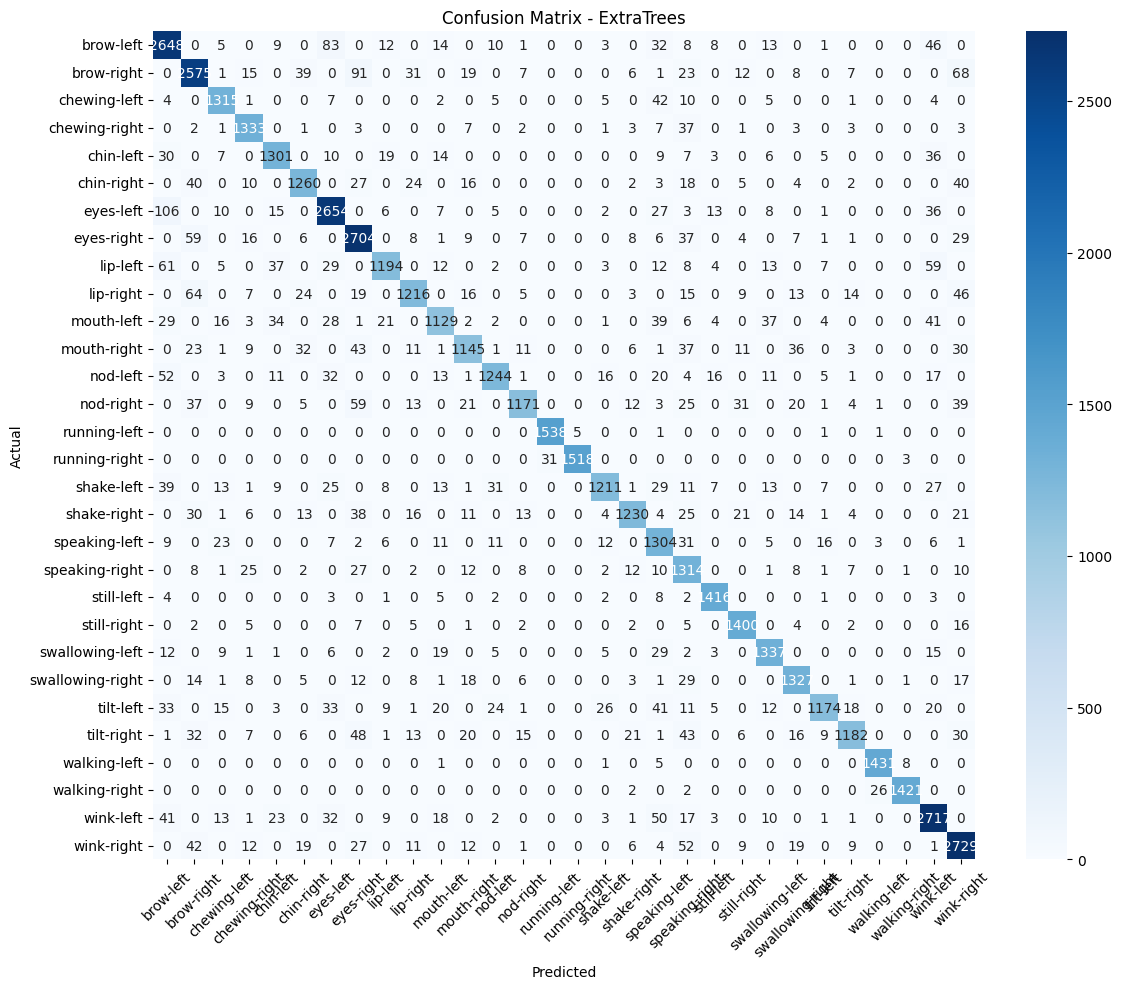

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_et)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - ExtraTrees")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

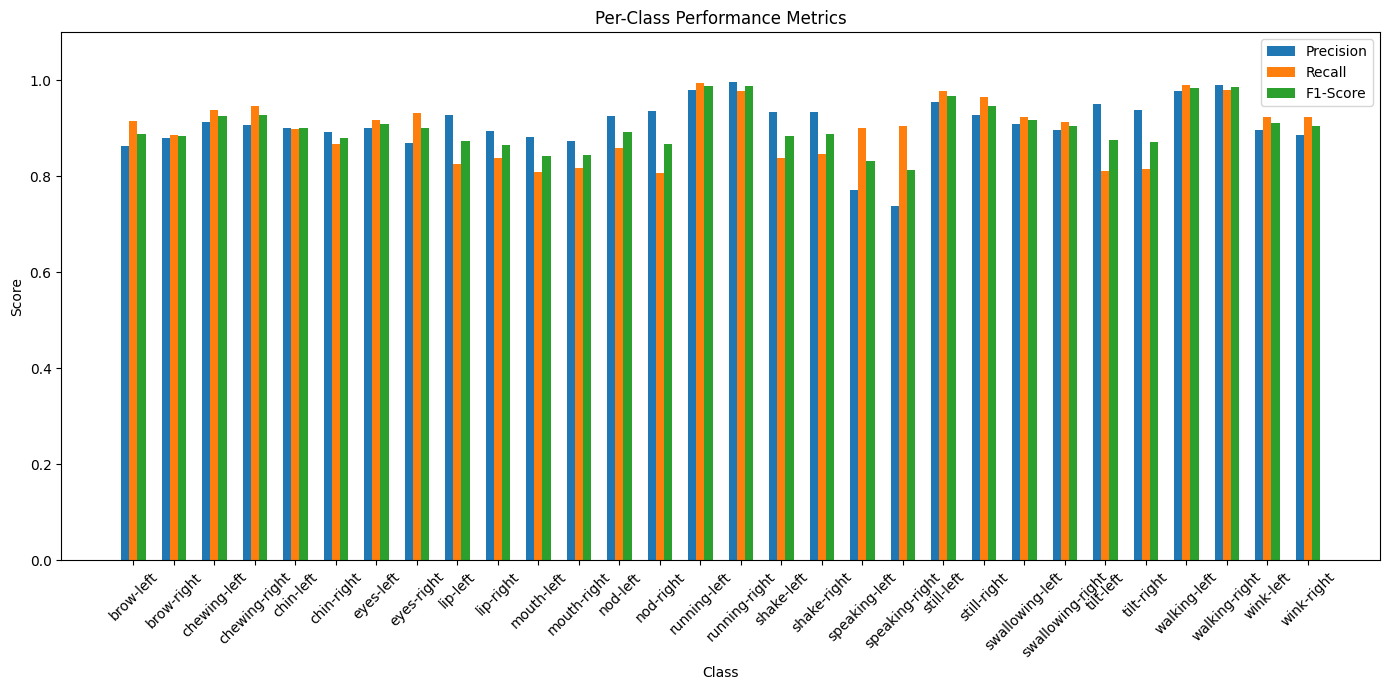

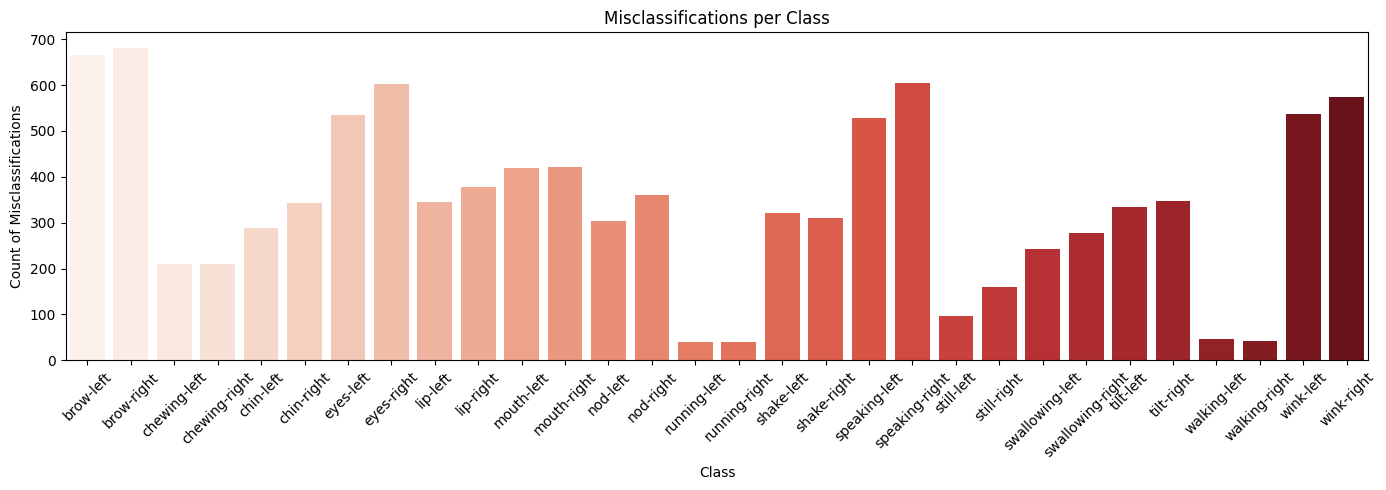

In [27]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Person with highest accuracy
best_et_person = df_person_scores_et.loc[df_person_scores_et['Accuracy'].idxmax()]
print(f"Highest Accuracy for ExtraTrees: {best_et_person['Accuracy']:.2%} by Person {int(best_et_person['person_id'])}")

Highest Accuracy for ExtraTrees: 98.25% by Person 10


In [29]:
# Person with highest F1-score
best_et_person = df_person_scores_et.loc[df_person_scores_et['F1-Score'].idxmax()]
print(f"Highest F1-score: {best_et_person['F1-Score']:.2%} by Person {int(best_et_person['person_id'])}")

Highest F1-score: 98.34% by Person 27


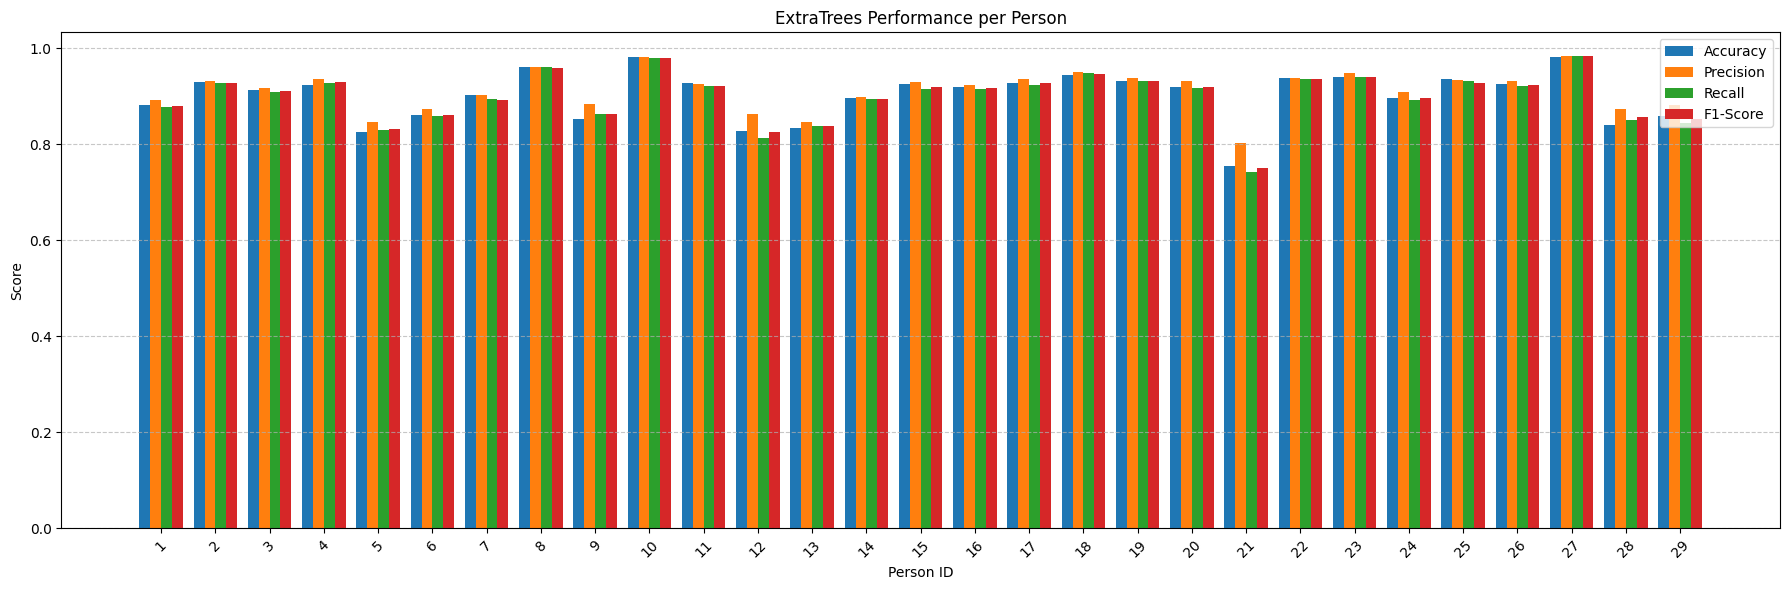

In [30]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores_et))
width = 0.2

plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores_et[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores_et['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("ExtraTrees Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Random Forest Classifier**

In [31]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Training the model
rf_model.fit(X_train, y_train)

# Per-person evaluation
person_scores_rf = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred_person = rf_model.predict(X_person)

    acc = accuracy_score(y_person, y_pred_person)
    prec = precision_score(y_person, y_pred_person, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred_person, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred_person, average='macro', zero_division=0)

    person_scores_rf.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores_rf = pd.DataFrame(person_scores_rf)

# Evaluation
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")
print(classification_report(y_test, rf_preds, target_names=le.classes_))

Random Forest Accuracy: 88.87%
                  precision    recall  f1-score   support

       brow-left       0.85      0.90      0.88      2893
      brow-right       0.87      0.87      0.87      2903
    chewing-left       0.90      0.92      0.91      1401
   chewing-right       0.89      0.93      0.91      1407
       chin-left       0.89      0.88      0.89      1447
      chin-right       0.87      0.85      0.86      1451
       eyes-left       0.88      0.91      0.90      2893
      eyes-right       0.86      0.92      0.89      2903
        lip-left       0.91      0.82      0.86      1446
       lip-right       0.87      0.83      0.85      1451
      mouth-left       0.85      0.80      0.82      1397
     mouth-right       0.84      0.79      0.81      1401
        nod-left       0.91      0.85      0.88      1447
       nod-right       0.92      0.80      0.86      1451
    running-left       0.98      0.99      0.98      1546
   running-right       0.99      0.98   

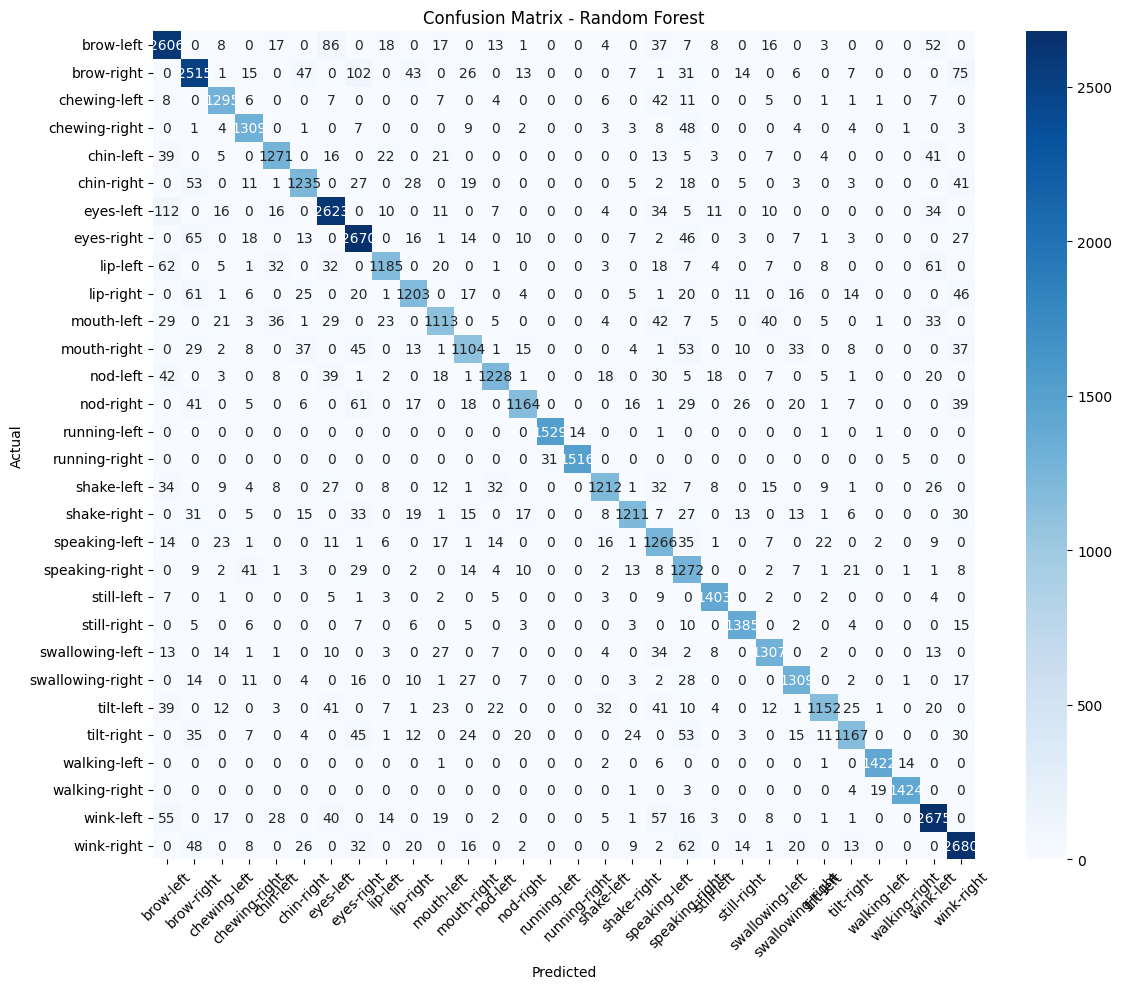

In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

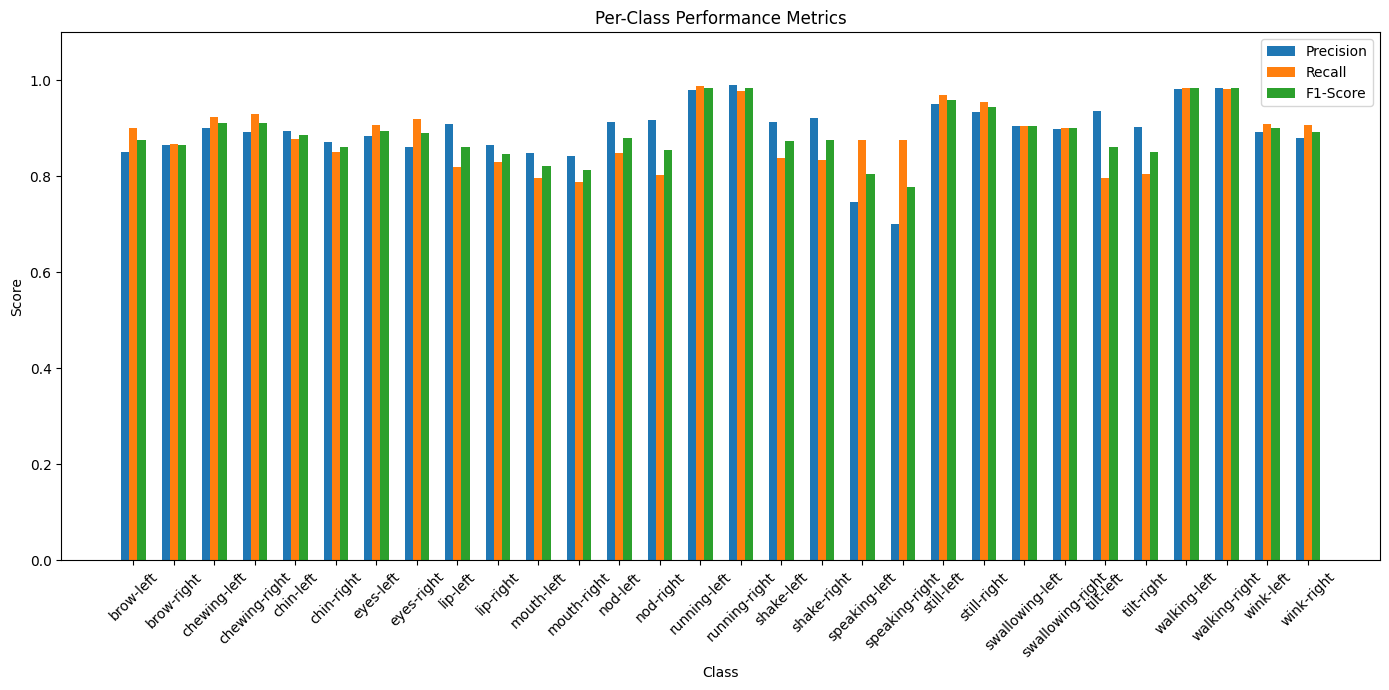

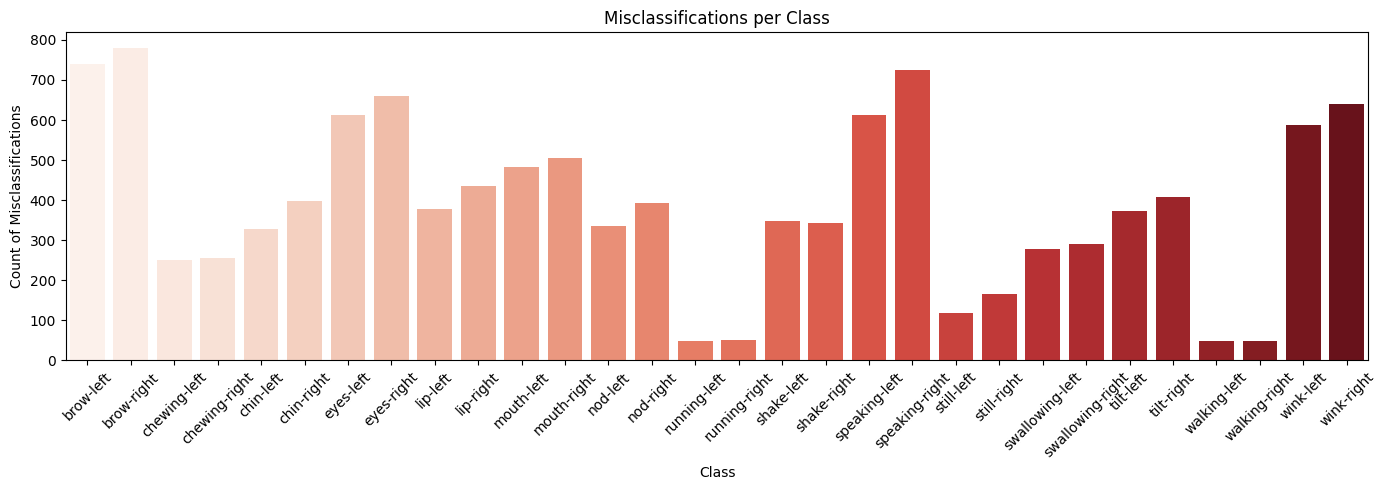

In [34]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Person with highest accuracy
best_rf_person = df_person_scores_rf.loc[df_person_scores_rf['Accuracy'].idxmax()]
print(f"Highest Accuracy for Random Forest: {best_rf_person['Accuracy']:.2%} by Person {int(best_rf_person['person_id'])}")

Highest Accuracy for Random Forest: 97.85% by Person 10


In [36]:
# Person with highest F1 score
best_rf_person = df_person_scores_rf.loc[df_person_scores_rf['F1-Score'].idxmax()]
print(f"Highest F1-score for Random Forest: {best_rf_person['F1-Score']:.2%} by Person {int(best_rf_person['person_id'])}")

Highest F1-score for Random Forest: 97.63% by Person 10


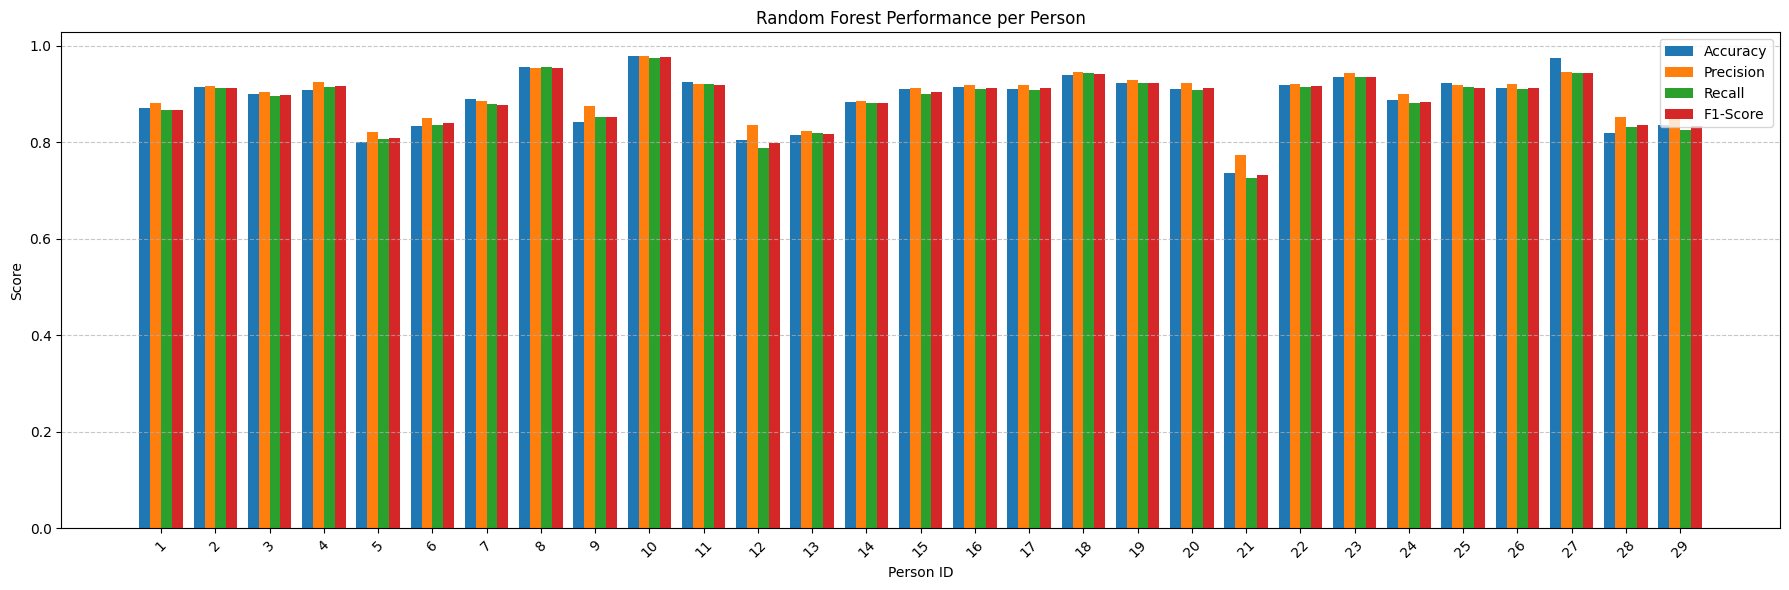

In [37]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores_rf))
width = 0.2

plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores_rf[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores_rf['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("Random Forest Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Voting Classifier**

In [9]:
# Defining individual models
model_lgb = LGBMClassifier(
    objective='multiclass',
    num_class=len(le.classes_),
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    random_state=42,
    n_estimators=1000
)
model_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    max_depth=10,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model_et = ExtraTreesClassifier(n_estimators=400, random_state=42)

# Voting Classifier (soft voting)
voting_clf = VotingClassifier(
    estimators=[
        ('lgb', model_lgb),
        ('xgb', model_xgb),
        ('et', model_et)
    ],
    voting='soft',
    weights=[4, 2, 1]  # More weight to LGBM
)
# Training
voting_clf.fit(X_train, y_train)

# Per-person evaluation
person_scores_vote = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred_person = voting_clf.predict(X_person)

    acc = accuracy_score(y_person, y_pred_person)
    prec = precision_score(y_person, y_pred_person, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred_person, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred_person, average='macro', zero_division=0)

    person_scores_vote.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores_vote = pd.DataFrame(person_scores_vote)

# Evaluation
y_pred = voting_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.502843 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31381
[LightGBM] [Info] Number of data points in the train set: 209076, number of used features: 158
[LightGBM] [Info] Start training from score -2.894109
[LightGBM] [Info] Start training from score -2.890831
[LightGBM] [Info] Start training from score -3.619039
[LightGBM] [Info] Start training from score -3.615299
[LightGBM] [Info] Start training from score -3.587429
[LightGBM] [Info] Start training from score -3.583978
[LightGBM] [Info] Start training from score -2.894023
[LightGBM] [Info] Start training from score -2.890831
[LightGBM] [Info] Start training from score -3.587602
[LightGBM] [Info] Start training from score -3.583978
[LightGBM] [Info] Start training from score -3.622434
[LightGBM] [Info] Start training from score -3.618860
[LightGBM] [Info] Start training from score -3.587084
[Light

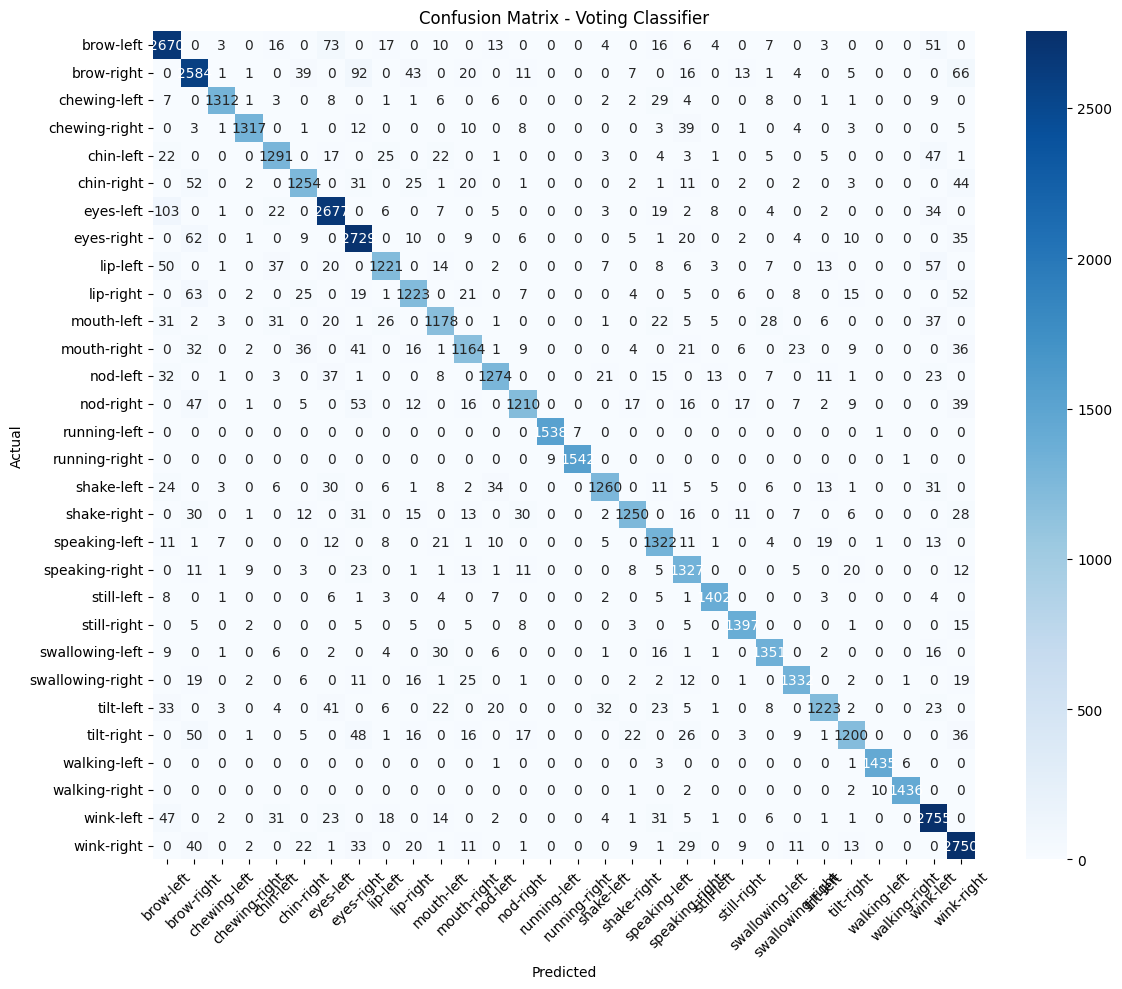

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Voting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

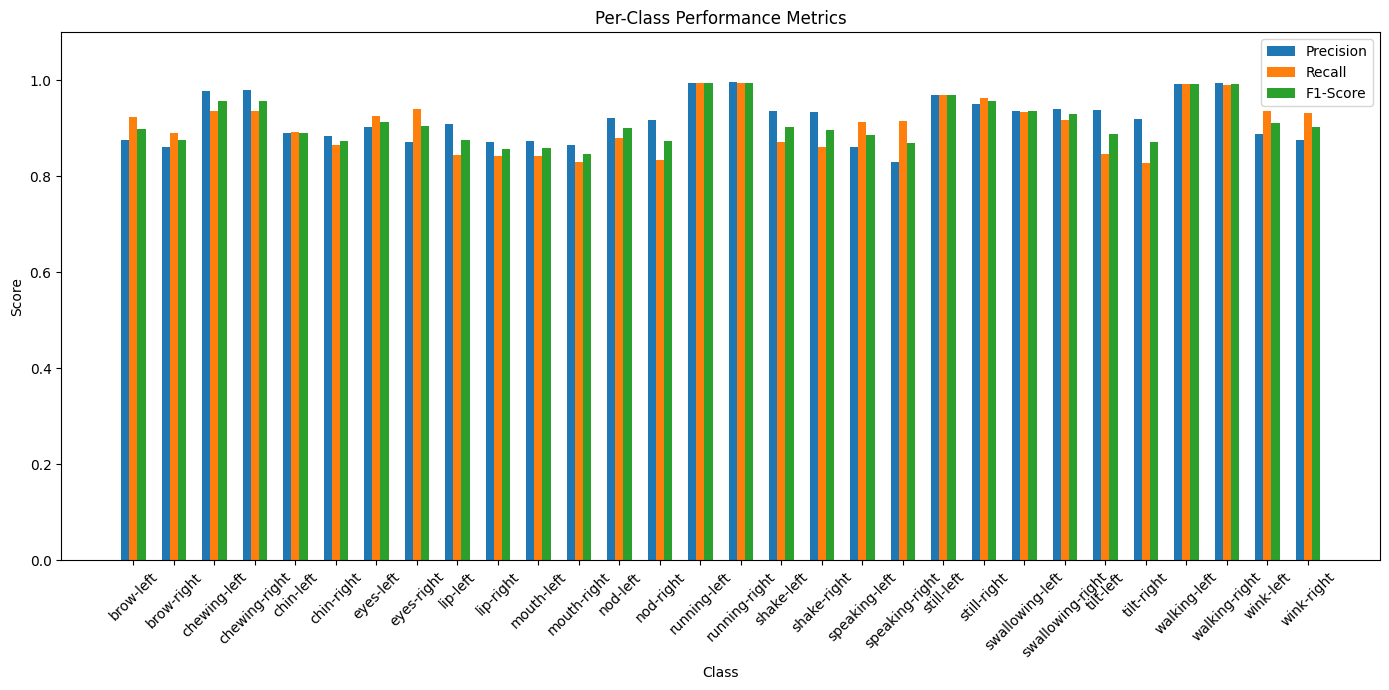

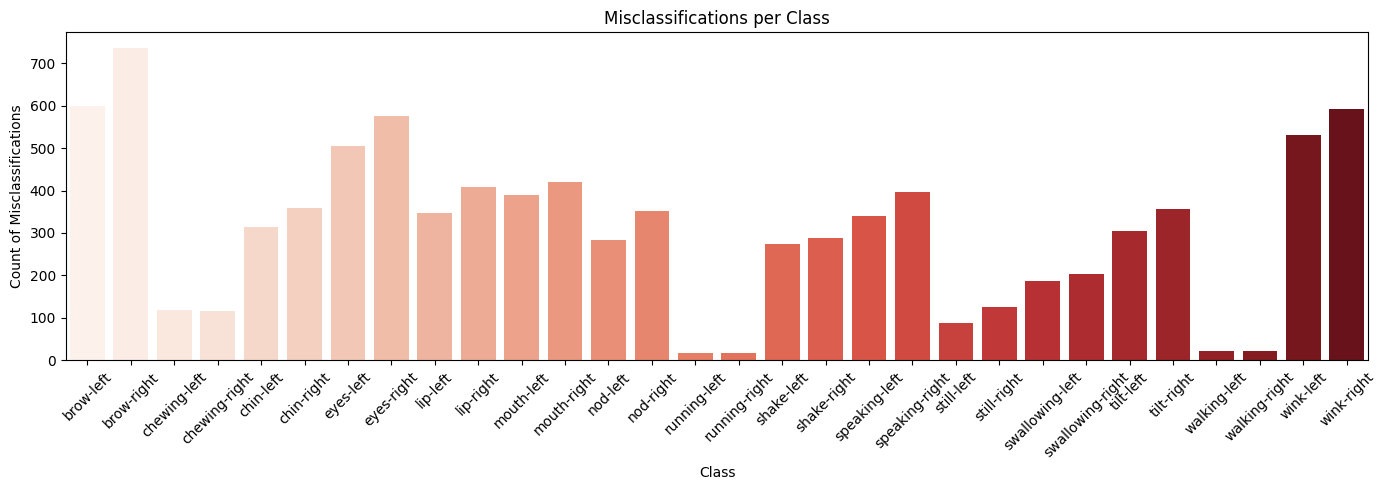

In [12]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Person with highest accuracy
best_vote_person = df_person_scores_vote.loc[df_person_scores_vote['Accuracy'].idxmax()]
print(f"Highest Accuracy for Voting Classifier: {best_vote_person['Accuracy']:.2%} by Person ID: {int(best_vote_person['person_id'])}")

Highest Accuracy for Voting Classifier: 99.04% by Person ID: 27


In [14]:
# Person with highest F1-score
best_vote_person = df_person_scores_vote.loc[df_person_scores_vote['F1-Score'].idxmax()]
print(f"Highest F1-score for Voting Classifier: {best_vote_person['F1-Score']:.2%} by Person {int(best_vote_person['person_id'])}")

Highest F1-score for Voting Classifier: 99.11% by Person 27


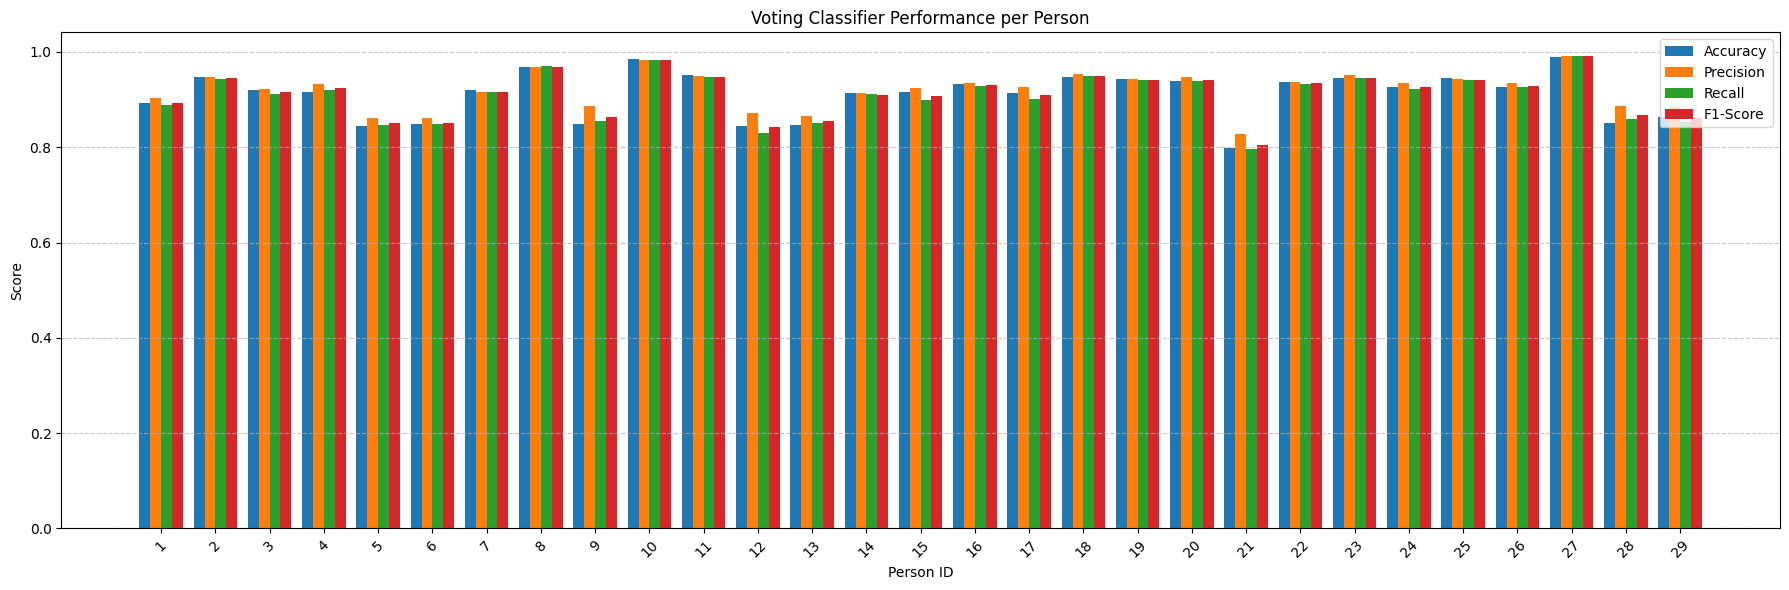

In [15]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores_vote))
width = 0.2

plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores_vote[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores_vote['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("Voting Classifier Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()